# 2-5. 카이제곱 독립성 검정

성별과 서비스 만족도가 서로 관련 있는지 확인한다.

- 두 변수 모두 범주형이므로 카이제곱 독립성 검정을 사용한다.
- 성별에 따라 만족도 분포가 달라지는지 검정한다.

In [8]:
import pandas as pd
from scipy import stats
from matplotlib import pyplot as plt

# macOS 한글 폰트를 그래프 기본 글꼴로 설정한다.
plt.rcParams["font.family"] = "Apple SD Gothic Neo"
plt.rcParams["axes.unicode_minus"] = False

# 성별과 만족도 데이터를 읽는다.
satisfaction_df = pd.read_csv(
    "datas2/성별에따른만족도.csv",
    encoding="euc-kr"
)

# 데이터 일부와 열 이름을 확인한다.
print(satisfaction_df.head())
print(satisfaction_df.columns)

   만족도  성별
0  불만족  남성
1   보통  여성
2  불만족  여성
3   보통  남성
4   만족  여성
Index(['만족도', '성별'], dtype='str')


## 1. 교차표와 가설 설정

성별과 만족도 분포를 교차표로 확인한다.

- 귀무가설(H₀): 성별과 만족도는 서로 독립이다.
- 대립가설(H₁): 성별과 만족도는 서로 독립이 아니다.

In [9]:
# 성별을 행, 만족도를 열로 하는 교차표를 만든다.
# 각 셀은 해당 성별·만족도 조합에 속하는 사람 수다.
contingency_table = pd.crosstab(
    satisfaction_df["성별"],
    satisfaction_df["만족도"]
)

# 관측된 빈도표를 출력한다.
contingency_table

만족도,만족,보통,불만족
성별,,,
남성,50,40,10
여성,40,30,30


성별별 만족도 비율(%)


만족도,만족,보통,불만족
성별,,,
남성,50.0,40.0,10.0
여성,40.0,30.0,30.0


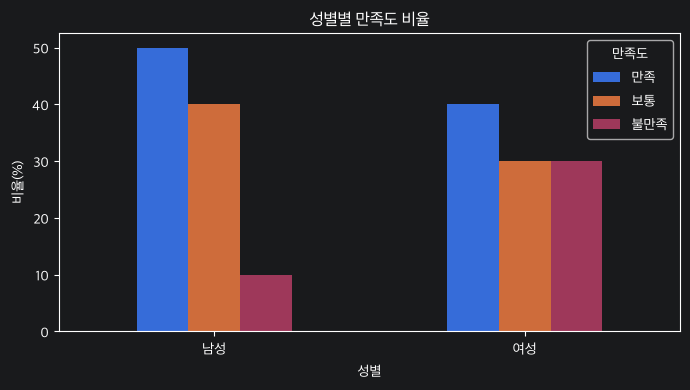

In [10]:
# 각 성별 안에서 만족도 비율(%)을 계산한다.
# axis=0은 행 단위로 나눈다는 뜻이다.
satisfaction_ratio = contingency_table.div(
    contingency_table.sum(axis=1),
    axis=0
) * 100

print("성별별 만족도 비율(%)")
display(satisfaction_ratio.round(1))

# 성별별 만족도 비율을 막대그래프로 그린다.
satisfaction_ratio.plot(
    kind="bar",
    figsize=(7, 4)
)

plt.ylabel("비율(%)")
plt.title("성별별 만족도 비율")
plt.xticks(rotation=0)
plt.legend(title="만족도")
plt.tight_layout()
plt.show()

## 2. 카이제곱 독립성 검정

교차표의 실제 관측 빈도와, 성별·만족도가 독립일 때 기대되는 빈도 차이를 검정한다.

In [11]:
# 교차표를 입력으로 카이제곱 독립성 검정을 수행한다.
# chi2: 카이제곱 통계량
# p_value: 귀무가설 아래에서 현재와 같은 차이가 나타날 확률
# dof: 자유도
# expected: 두 변수가 독립일 때 각 셀에서 기대되는 빈도
chi2, p_value, dof, expected = stats.chi2_contingency(
    contingency_table
)

print(f"카이제곱 통계량: {chi2:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"자유도: {dof}")

# 유의수준 0.05를 기준으로 결과를 해석한다.
if p_value <= 0.05:
    print("귀무가설을 기각한다: 성별과 만족도는 서로 관련이 있다.")
else:
    print("귀무가설을 기각하지 못한다: 성별과 만족도가 관련 있다고 할 충분한 증거가 없다.")

카이제곱 통계량: 12.5397
p-value: 0.0019
자유도: 2
귀무가설을 기각한다: 성별과 만족도는 서로 관련이 있다.


In [12]:
# 독립을 가정했을 때의 기대 빈도를 교차표 형태로 만든다.
expected_table = pd.DataFrame(
    expected,
    index=contingency_table.index,
    columns=contingency_table.columns
)

print("독립을 가정했을 때의 기대 빈도")
display(expected_table.round(2))

# 기대 빈도가 모두 5 이상인지 확인한다.
# 일반적으로 기대 빈도가 너무 작으면 카이제곱 검정 결과가 불안정할 수 있다.
print(f"가장 작은 기대 빈도: {expected_table.to_numpy().min():.2f}")

독립을 가정했을 때의 기대 빈도


만족도,만족,보통,불만족
성별,,,
남성,45.0,35.0,20.0
여성,45.0,35.0,20.0


가장 작은 기대 빈도: 20.00


In [13]:
# 표준화 잔차를 계산한다.
# 양수: 실제 관측 빈도가 기대 빈도보다 많음
# 음수: 실제 관측 빈도가 기대 빈도보다 적음
standardized_residuals = (
                                 contingency_table - expected_table
                         ) / (expected_table ** 0.5)

print("표준화 잔차")
display(standardized_residuals.round(2))

표준화 잔차


만족도,만족,보통,불만족
성별,,,
남성,0.75,0.85,-2.24
여성,-0.75,-0.85,2.24


In [14]:
# Cramér's V로 두 범주형 변수의 관계 크기를 계산한다.
# 0에 가까울수록 약한 관계, 1에 가까울수록 강한 관계다.
sample_size = contingency_table.to_numpy().sum()
smaller_dimension = min(
    contingency_table.shape[0] - 1,
    contingency_table.shape[1] - 1
)

cramers_v = (chi2 / (sample_size * smaller_dimension)) ** 0.5

print(f"Cramér's V: {cramers_v:.4f}")

Cramér's V: 0.2504


## 3. 분석 결과

- 카이제곱 독립성 검정 결과 p-value는 0.0019로 유의수준 0.05보다 작았다.
- 따라서 성별과 만족도는 서로 독립이라는 귀무가설을 기각했다.
- 성별과 만족도 분포는 통계적으로 관련이 있었다.
- 남성의 불만족 비율은 10%로 기대 빈도보다 낮았고, 여성의 불만족 비율은 30%로 기대 빈도보다 높았다.
- 표준화 잔차에서도 불만족 범주의 차이가 가장 크게 나타났다.
- Cramér's V는 0.2504로, 관계는 유의하지만 크기는 아주 강한 수준은 아니었다.
- 이 결과는 성별이 만족도를 직접 결정한다는 인과관계를 뜻하지는 않는다.